<a href="https://colab.research.google.com/github/guilhermelaviola/AppliedDifferentialMathematics/blob/main/Class14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Rolle's Theorem & Mean Value Theorem**
**Rolle's Theorem** states that if a function is continuous on a closed interval $[a, b]$, differentiable on the open interval $(a, b)$, and shares equal values at its endpoints such that $f(a) = f(b)$, then there must exist at least one point $c$ within $(a, b)$ where the instantaneous rate of change is zero, meaning the derivative $f'(c) = 0$. The **Mean Value Theorem (MVT)** expands this concept into a more general rule by removing the requirement for equal endpoints: it guarantees that for any function continuous on $[a, b]$ and differentiable on $(a, b)$, there is at least one point $c$ in $(a, b)$ where the instantaneous rate of change equals the average rate of change over the entire interval, mathematically expressed as

$$f'(c) = \frac{f(b) - f(a)}{b - a}$$

 making Rolle's Theorem a specific, special case of the Mean Value Theorem where the average rate of change happens to be zero.

## **Example: Mean Value Theorem**
The following example uses sympy to symbolically find the point $c$ guaranteed by the Mean Value Theorem for a specific function, along with a matplotlib script to visualize how the instantaneous slope matches the average slope.

In [1]:
# Importing all the necessary libraries and resources:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [2]:
# Defining the function and interval symbolically using SymPy:
x = sp.Symbol('x')
f_expr = x**3 - 3*x**2 + 2  # Example function: f(x) = x^3 - 3x^2 + 2
a, b = 0, 3                  # Closed interval [a, b]

In [4]:
# Calculating the average rate of change (secant slope):
fa = f_expr.subs(x, a)
fb = f_expr.subs(x, b)
secant_slope = (fb - fa) / (b - a)

# Finding the derivative f'(x):
f_prime = sp.diff(f_expr, x)

In [6]:
# Solving f'(c) = secant_slope for c within (a, b):
solutions = sp.solve(sp.Eq(f_prime, secant_slope), x)
# Filtering solutions to find the 'c' that lies strictly inside our interval (0, 3):
c_val = [float(sol) for sol in solutions if a < sol < b][0]
print(f'Average rate of change (secant slope): {secant_slope}')
print(f'Value of c guaranteed by MVT: {c_val:.4f}')
print(f"f'(c) = {f_prime.subs(x, c_val):.4f}")

Average rate of change (secant slope): 0
Value of c guaranteed by MVT: 2.0000
f'(c) = 0.0000


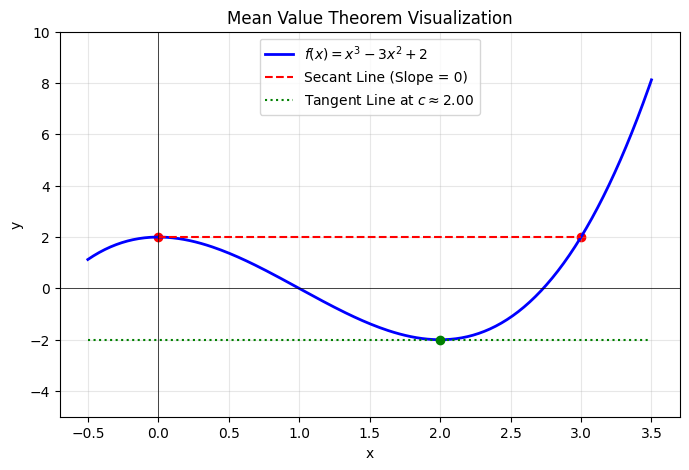

In [8]:
# Converting symbolic expression to a numerical function:
f_num = sp.lambdify(x, f_expr, 'numpy')
x_vals = np.linspace(a - 0.5, b + 0.5, 200)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, f_num(x_vals), label='$f(x) = x^3 - 3x^2 + 2$', color='blue', lw=2)

# Plotting the secant line between a and b:
plt.plot([a, b], [float(fa), float(fb)], color='red', linestyle='--',
         label=f'Secant Line (Slope = {secant_slope})')
plt.scatter([a, b], [float(fa), float(fb)], color='red')

# Plotting the tangent line at c:
fc_val = float(f_expr.subs(x, c_val))
tangent_line = secant_slope * (x_vals - c_val) + fc_val
plt.plot(x_vals, tangent_line, color='green', linestyle=':',
         label=f'Tangent Line at $c \\approx {c_val:.2f}$')
plt.scatter([c_val], [fc_val], color='green', zorder=5)

plt.title('Mean Value Theorem Visualization')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black',lw=0.5, ls='-')
plt.axvline(0, color='black',lw=0.5, ls='-')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-5, 10)
plt.show()